In [1]:
# https://www.kaggle.com/datasets/fivethirtyeight/uber-pickups-in-new-york-city?select=uber-raw-data-sep14.csv

In [12]:
# Uber NYC 데이터 시각화 템플릿 (Jupyter Notebook 용)

# 필요한 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display
import numpy as np
from pandas.plotting import parallel_coordinates

plt.rcParams['figure.dpi'] = 300

# 그래프 스타일 설정
sns.set(style="whitegrid")

In [13]:
FILE_PATH = "uber-raw-data-sep14.csv"
df = pd.read_csv(FILE_PATH)

df.head()

,Date/Time,Lat,Lon,Base
0,9/1/2014 0:01:00,40.2201,-74.0021,B02512
1,9/1/2014 0:01:00,40.7500,-74.0027,B02512
2,9/1/2014 0:03:00,40.7559,-73.9864,B02512
3,9/1/2014 0:06:00,40.7450,-73.9889,B02512
4,9/1/2014 0:11:00,40.8145,-73.9444,B02512


In [14]:
df.shape

(1028136, 4)

In [15]:
df.info()

# Date/Time : The date and time of the Uber pickup
# Lat : The latitude of the Uber pickup
# Lon : The longitude of the Uber pickup
# Base : The TLC base company code affiliated with the Uber pickup

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028136 entries, 0 to 1028135
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   Date/Time  1028136 non-null  object 
 1   Lat        1028136 non-null  float64
 2   Lon        1028136 non-null  float64
 3   Base       1028136 non-null  object 
dtypes: float64(2), object(2)
memory usage: 31.4+ MB


In [16]:
df.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

In [17]:
df.describe()

,Lat,Lon
count,1.028136e+06,1.028136e+06
mean,4.073922e+01,-7.397182e+01
std,4.082861e-02,5.831413e-02
min,3.998970e+01,-7.477360e+01
25%,4.072040e+01,-7.399620e+01
50%,4.074180e+01,-7.398310e+01
75%,4.076120e+01,-7.396280e+01
max,4.134760e+01,-7.271630e+01


In [18]:
df.select_dtypes(include=["number"]).skew()

Lat    0.461476
Lon    2.239341
dtype: float64

In [19]:
df.select_dtypes(include=["number"]).kurt()

Lat    10.180041
Lon    27.924359
dtype: float64

In [20]:
df.select_dtypes(include=["number"]).cov()

,Lat,Lon
Lat,0.001667,0.000110
Lon,0.000110,0.003401


In [21]:
df.select_dtypes(include=["number"]).corr(method="pearson")

,Lat,Lon
Lat,1.000000,0.046376
Lon,0.046376,1.000000


In [22]:
df["Date/Time"] = pd.to_datetime(df['Date/Time'])

df

,Date/Time,Lat,Lon,Base
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512
...,...,...,...,...
1028131,2014-09-30 22:57:00,40.7668,-73.9845,B02764
1028132,2014-09-30 22:57:00,40.6911,-74.1773,B02764
1028133,2014-09-30 22:58:00,40.8519,-73.9319,B02764
1028134,2014-09-30 22:58:00,40.7081,-74.0066,B02764


In [23]:
df["hour"] = df["Date/Time"].dt.hour

df

,Date/Time,Lat,Lon,Base,hour
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512,0
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512,0
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512,0
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512,0
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512,0
...,...,...,...,...,...
1028131,2014-09-30 22:57:00,40.7668,-73.9845,B02764,22
1028132,2014-09-30 22:57:00,40.6911,-74.1773,B02764,22
1028133,2014-09-30 22:58:00,40.8519,-73.9319,B02764,22
1028134,2014-09-30 22:58:00,40.7081,-74.0066,B02764,22


In [24]:
df["day_of_week"] = df['Date/Time'].dt.day_name()

df

,Date/Time,Lat,Lon,Base,hour,day_of_week
0,2014-09-01 00:01:00,40.2201,-74.0021,B02512,0,Monday
1,2014-09-01 00:01:00,40.7500,-74.0027,B02512,0,Monday
2,2014-09-01 00:03:00,40.7559,-73.9864,B02512,0,Monday
3,2014-09-01 00:06:00,40.7450,-73.9889,B02512,0,Monday
4,2014-09-01 00:11:00,40.8145,-73.9444,B02512,0,Monday
...,...,...,...,...,...,...
1028131,2014-09-30 22:57:00,40.7668,-73.9845,B02764,22,Tuesday
1028132,2014-09-30 22:57:00,40.6911,-74.1773,B02764,22,Tuesday
1028133,2014-09-30 22:58:00,40.8519,-73.9319,B02764,22,Tuesday
1028134,2014-09-30 22:58:00,40.7081,-74.0066,B02764,22,Tuesday


## 1. 시간 시각화 – 시간대별 탑승 수 추세 (Line Plot)

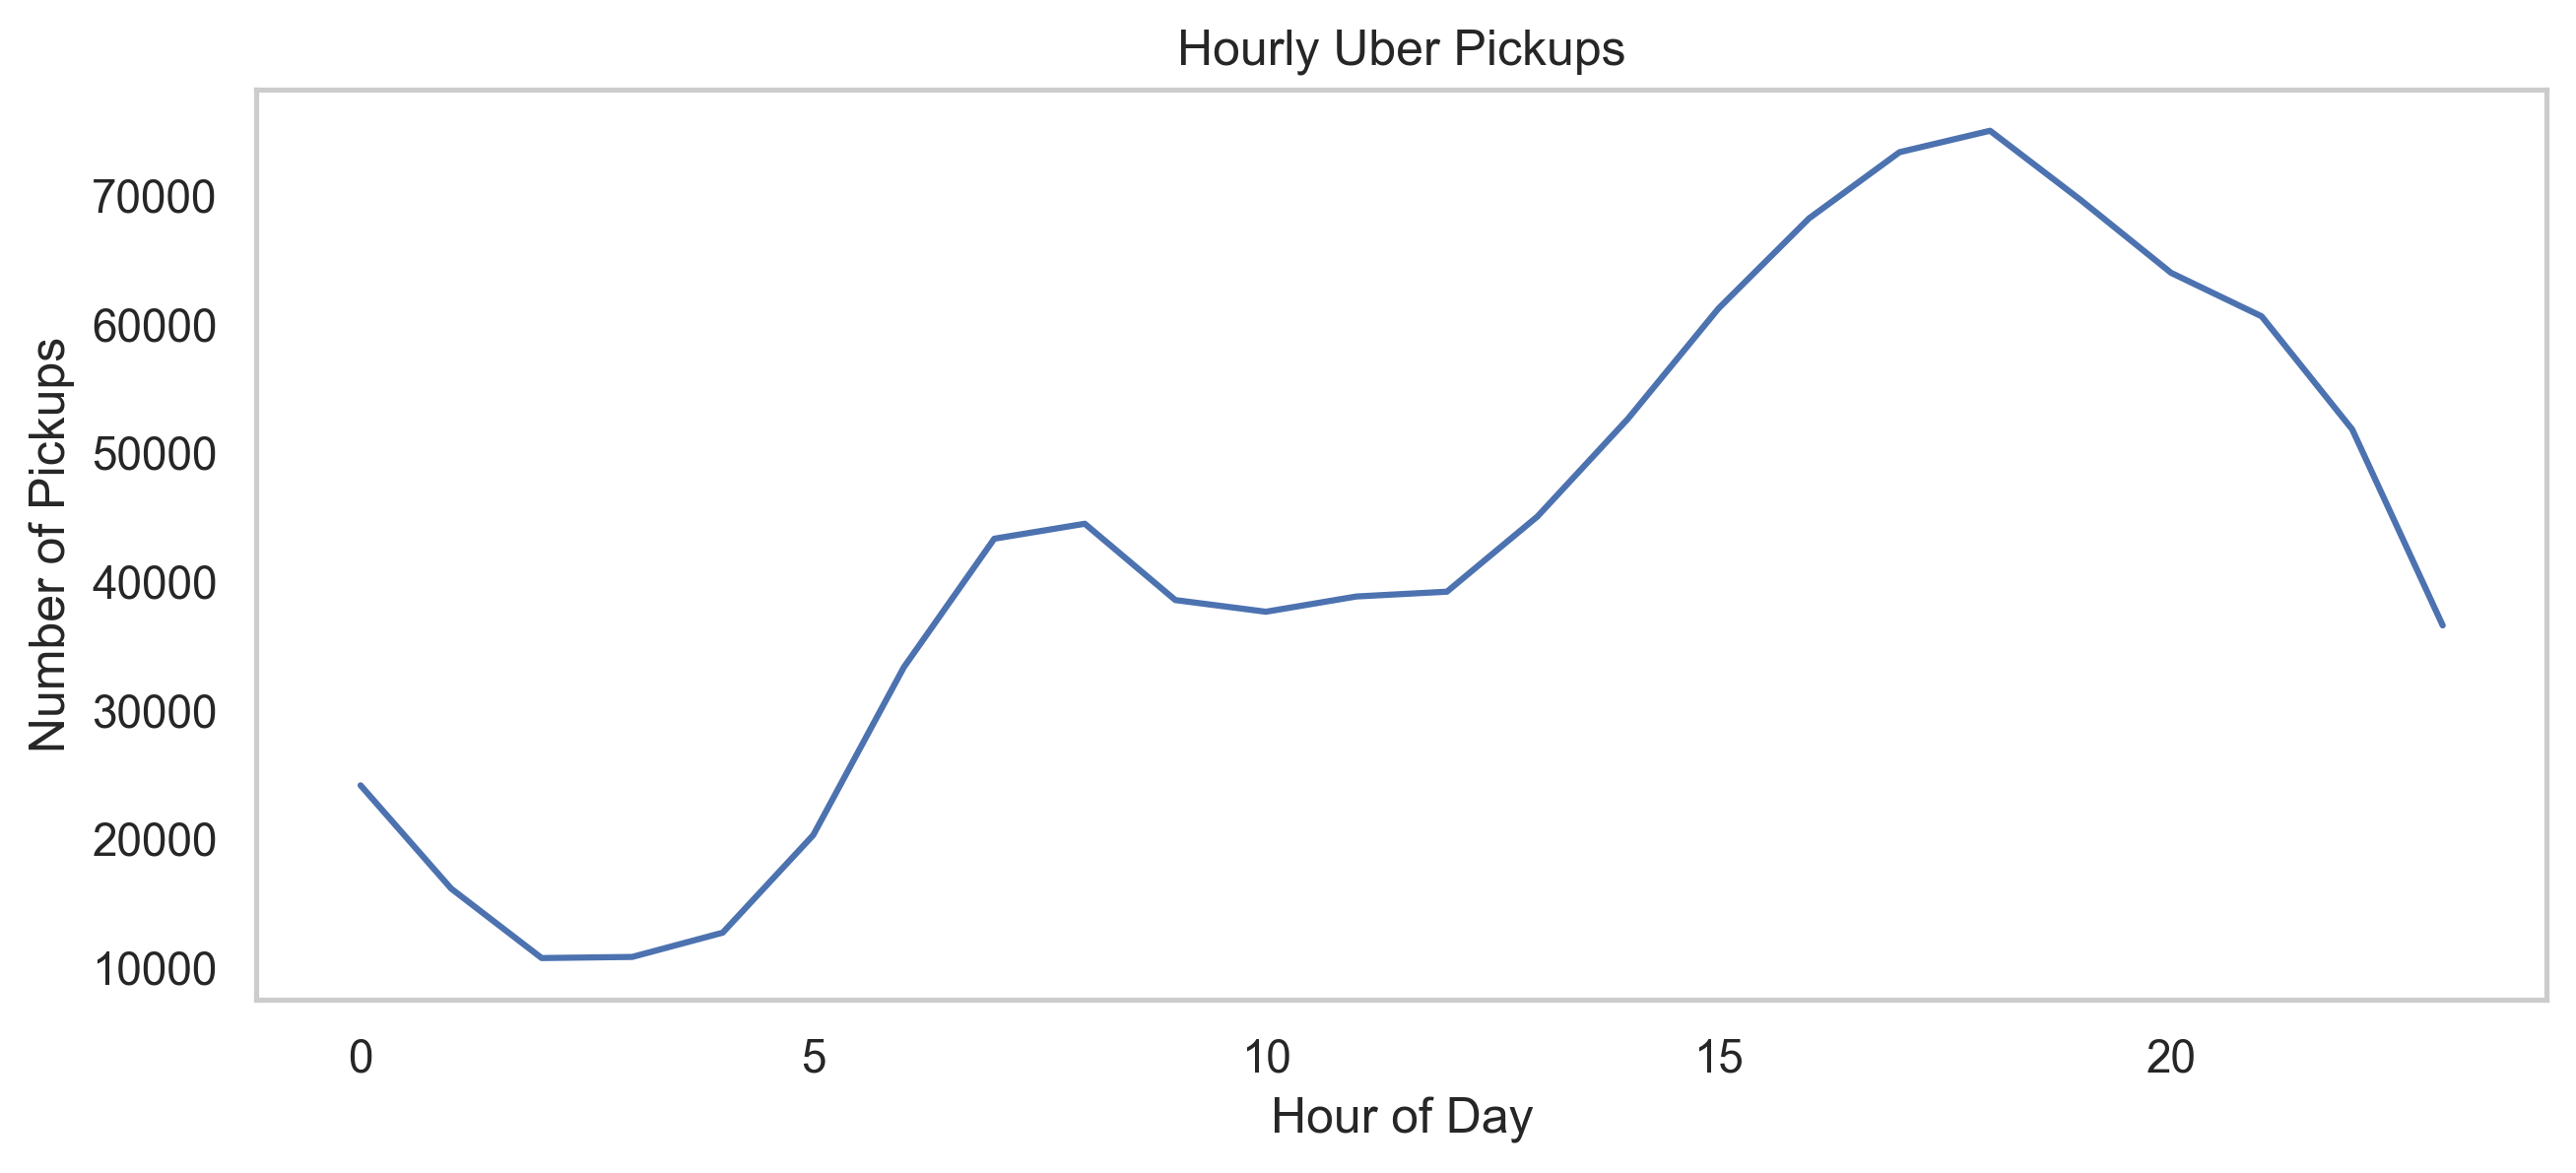

In [ ]:
plt.figure(figsize=(10, 4))  # 그래프의 크기를 가로 10, 세로 4로 설정
df["hour"].value_counts().sort_index().plot(kind="line")  
# 'hour' 열의 값 빈도를 계산하고 시간 순으로 정렬한 후 선 그래프로 그림

plt.title("Hourly Uber Pickups")  # 그래프 제목 설정
plt.xlabel("Hour of Day")  # x축 레이블 설정
plt.ylabel("Number of Pickups")  # y축 레이블 설정
plt.grid()  # 그래프에 격자 표시


# # 시간대별 탑승 수 집계
# hour_counts = df['hour'].value_counts().sort_index() # 시간대별 탑승 수 구한 후 sort_index()를 통해 시간 순서대로 정렬

# # Line Plot 그리기
# plt.figure(figsize=(10,5))
# sns.lineplot(x = hour_counts.index, y = hour_counts.values)

# plt.grid(False)
# plt.title("Hourly Uber Pickups")
# plt.ylabel("Number of Pickups")
# plt.xlabel("Hour of day")
# plt.show()

## 2. 비교 시각화 – 요일별 탑승 수 (Bar Plot)

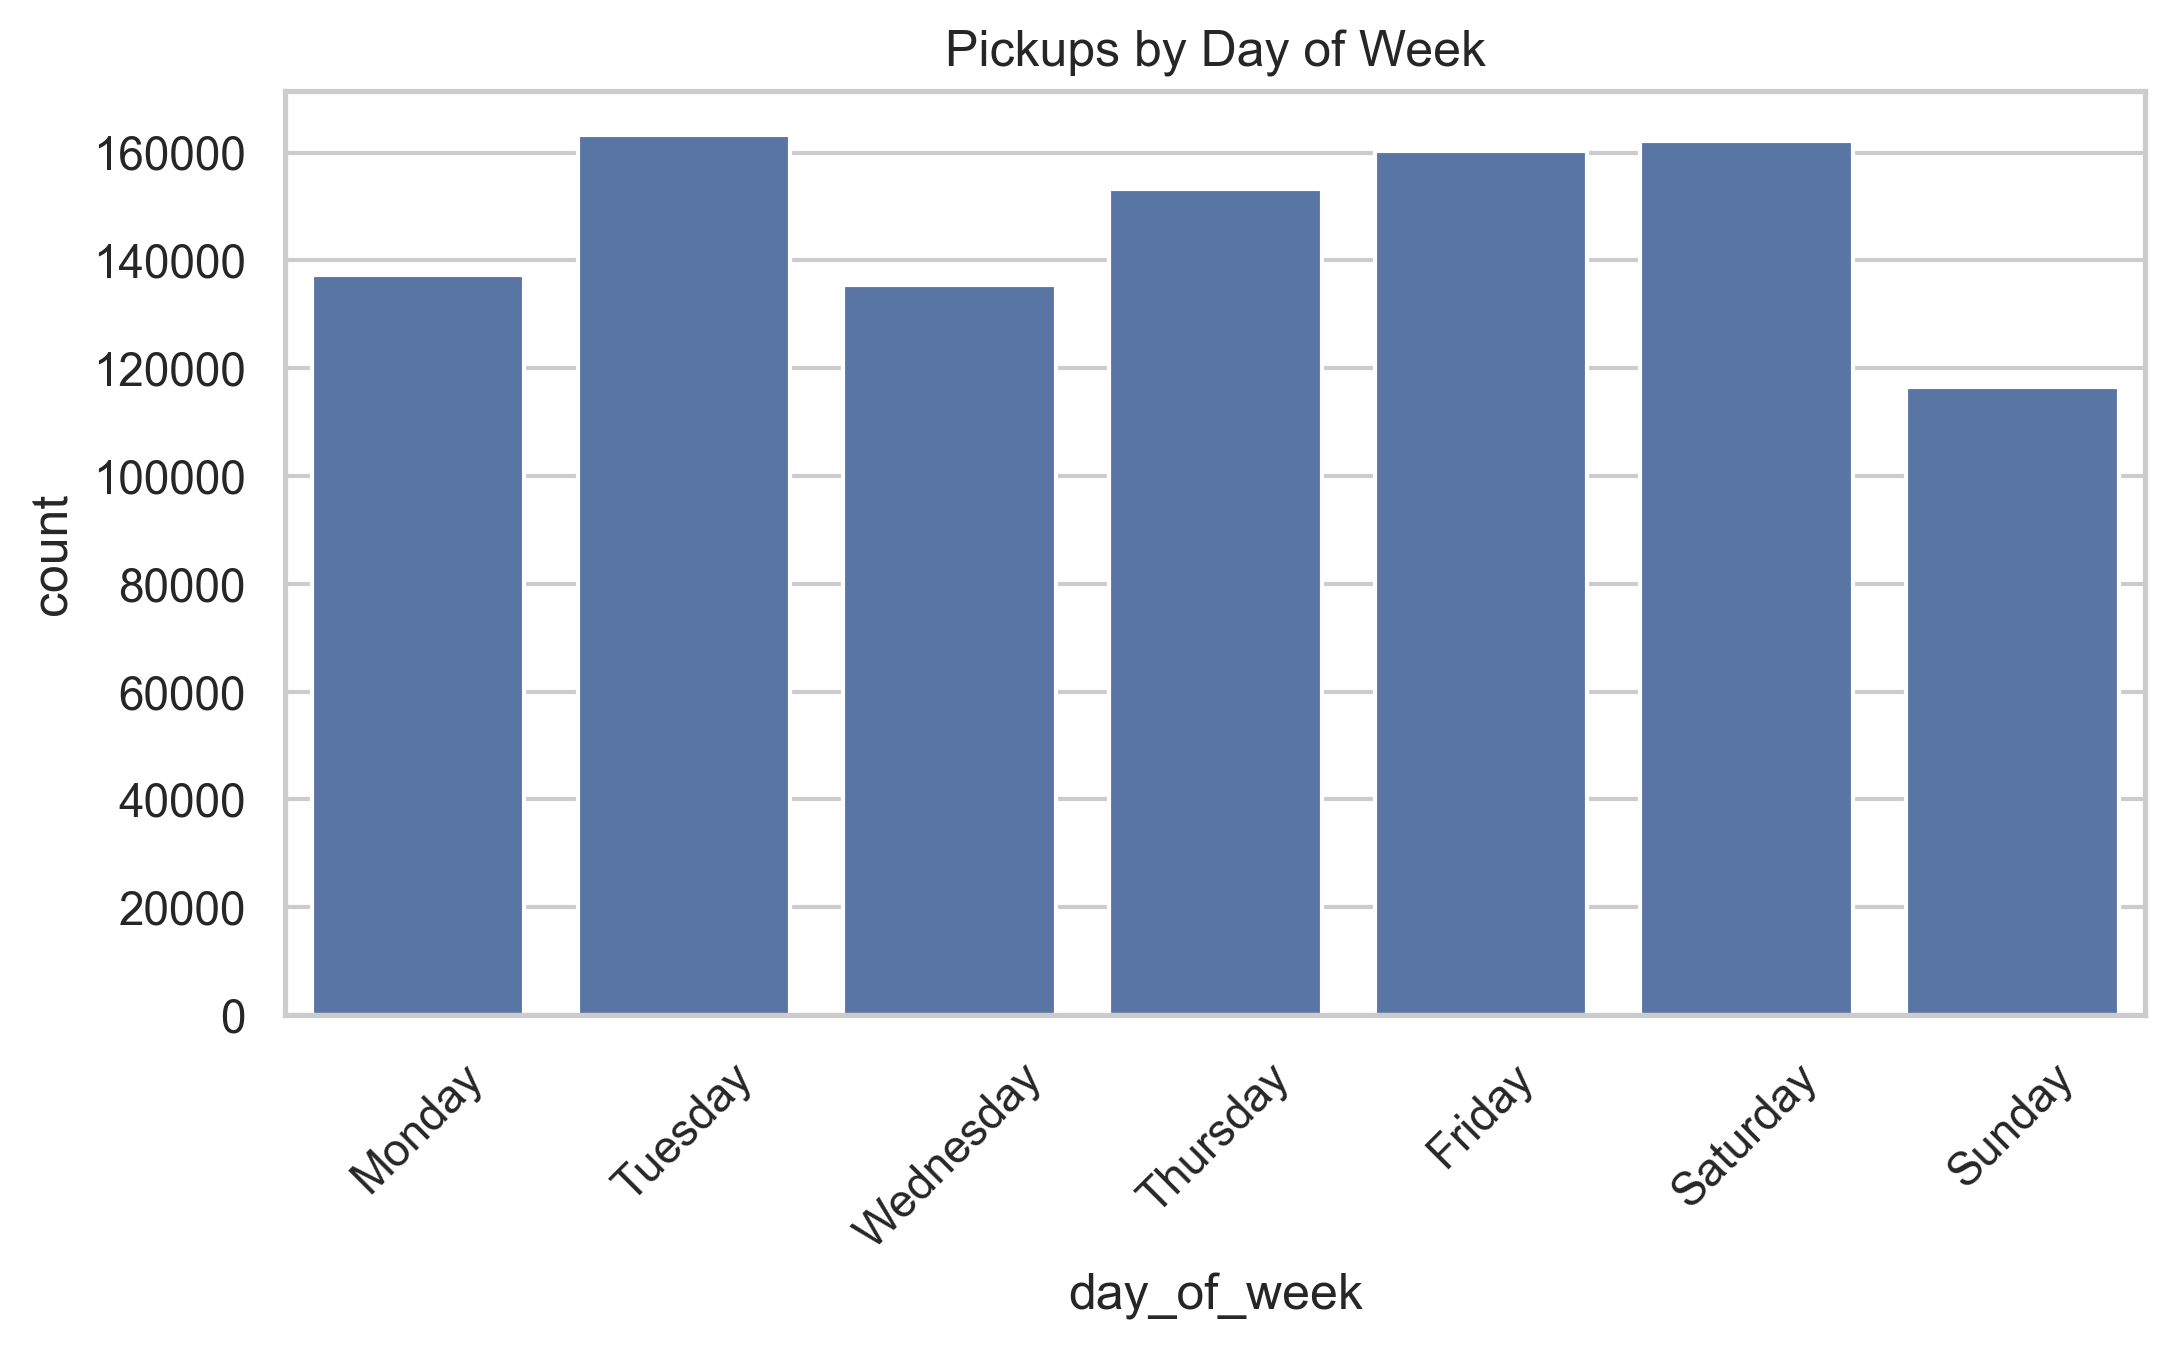

In [30]:
plt.figure(figsize=(8, 4))  # 그래프의 크기를 가로 8, 세로 4로 설정

sns.countplot(  # seaborn의 countplot을 사용하여 범주형 데이터의 빈도수를 시각화
    x="day_of_week",         # x축에 'day_of_week' 열 사용
    data=df,                 # 데이터프레임은 df 사용
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]  # 요일 순서를 지정하여 x축에 적용
)

plt.title("Pickups by Day of Week")  # 그래프 제목 설정

plt.xticks(rotation=45)  # x축 레이블(요일 이름)을 45도 회전시켜 가독성 향상

plt.show()  # 그래프를 화면에 출력

# # 요일 순서를 따르기 위해 groupby + reindex 사용
# day_order = ['Monday', "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
#     # 요일별 탑승 수 집계
# day_counts = df.groupby("day_of_week").size().reindex(day_order)

# # Bar plot 그리기 
# plt.figure(figsize=(10, 5))
# sns.barplot(x = day_counts.index, y = day_counts.values)

# plt.grid(axis='y')
# plt.title("Pickups by Day of Week")
# plt.xlabel("day_of_week")
# plt.ylabel("count")
# plt.xticks(rotation = 45) # X 축 레이블 회전
# plt.show()


## 3. 관계 시각화 – 요일 vs 시간별 탑승 수 히트맵 (Heatmap)

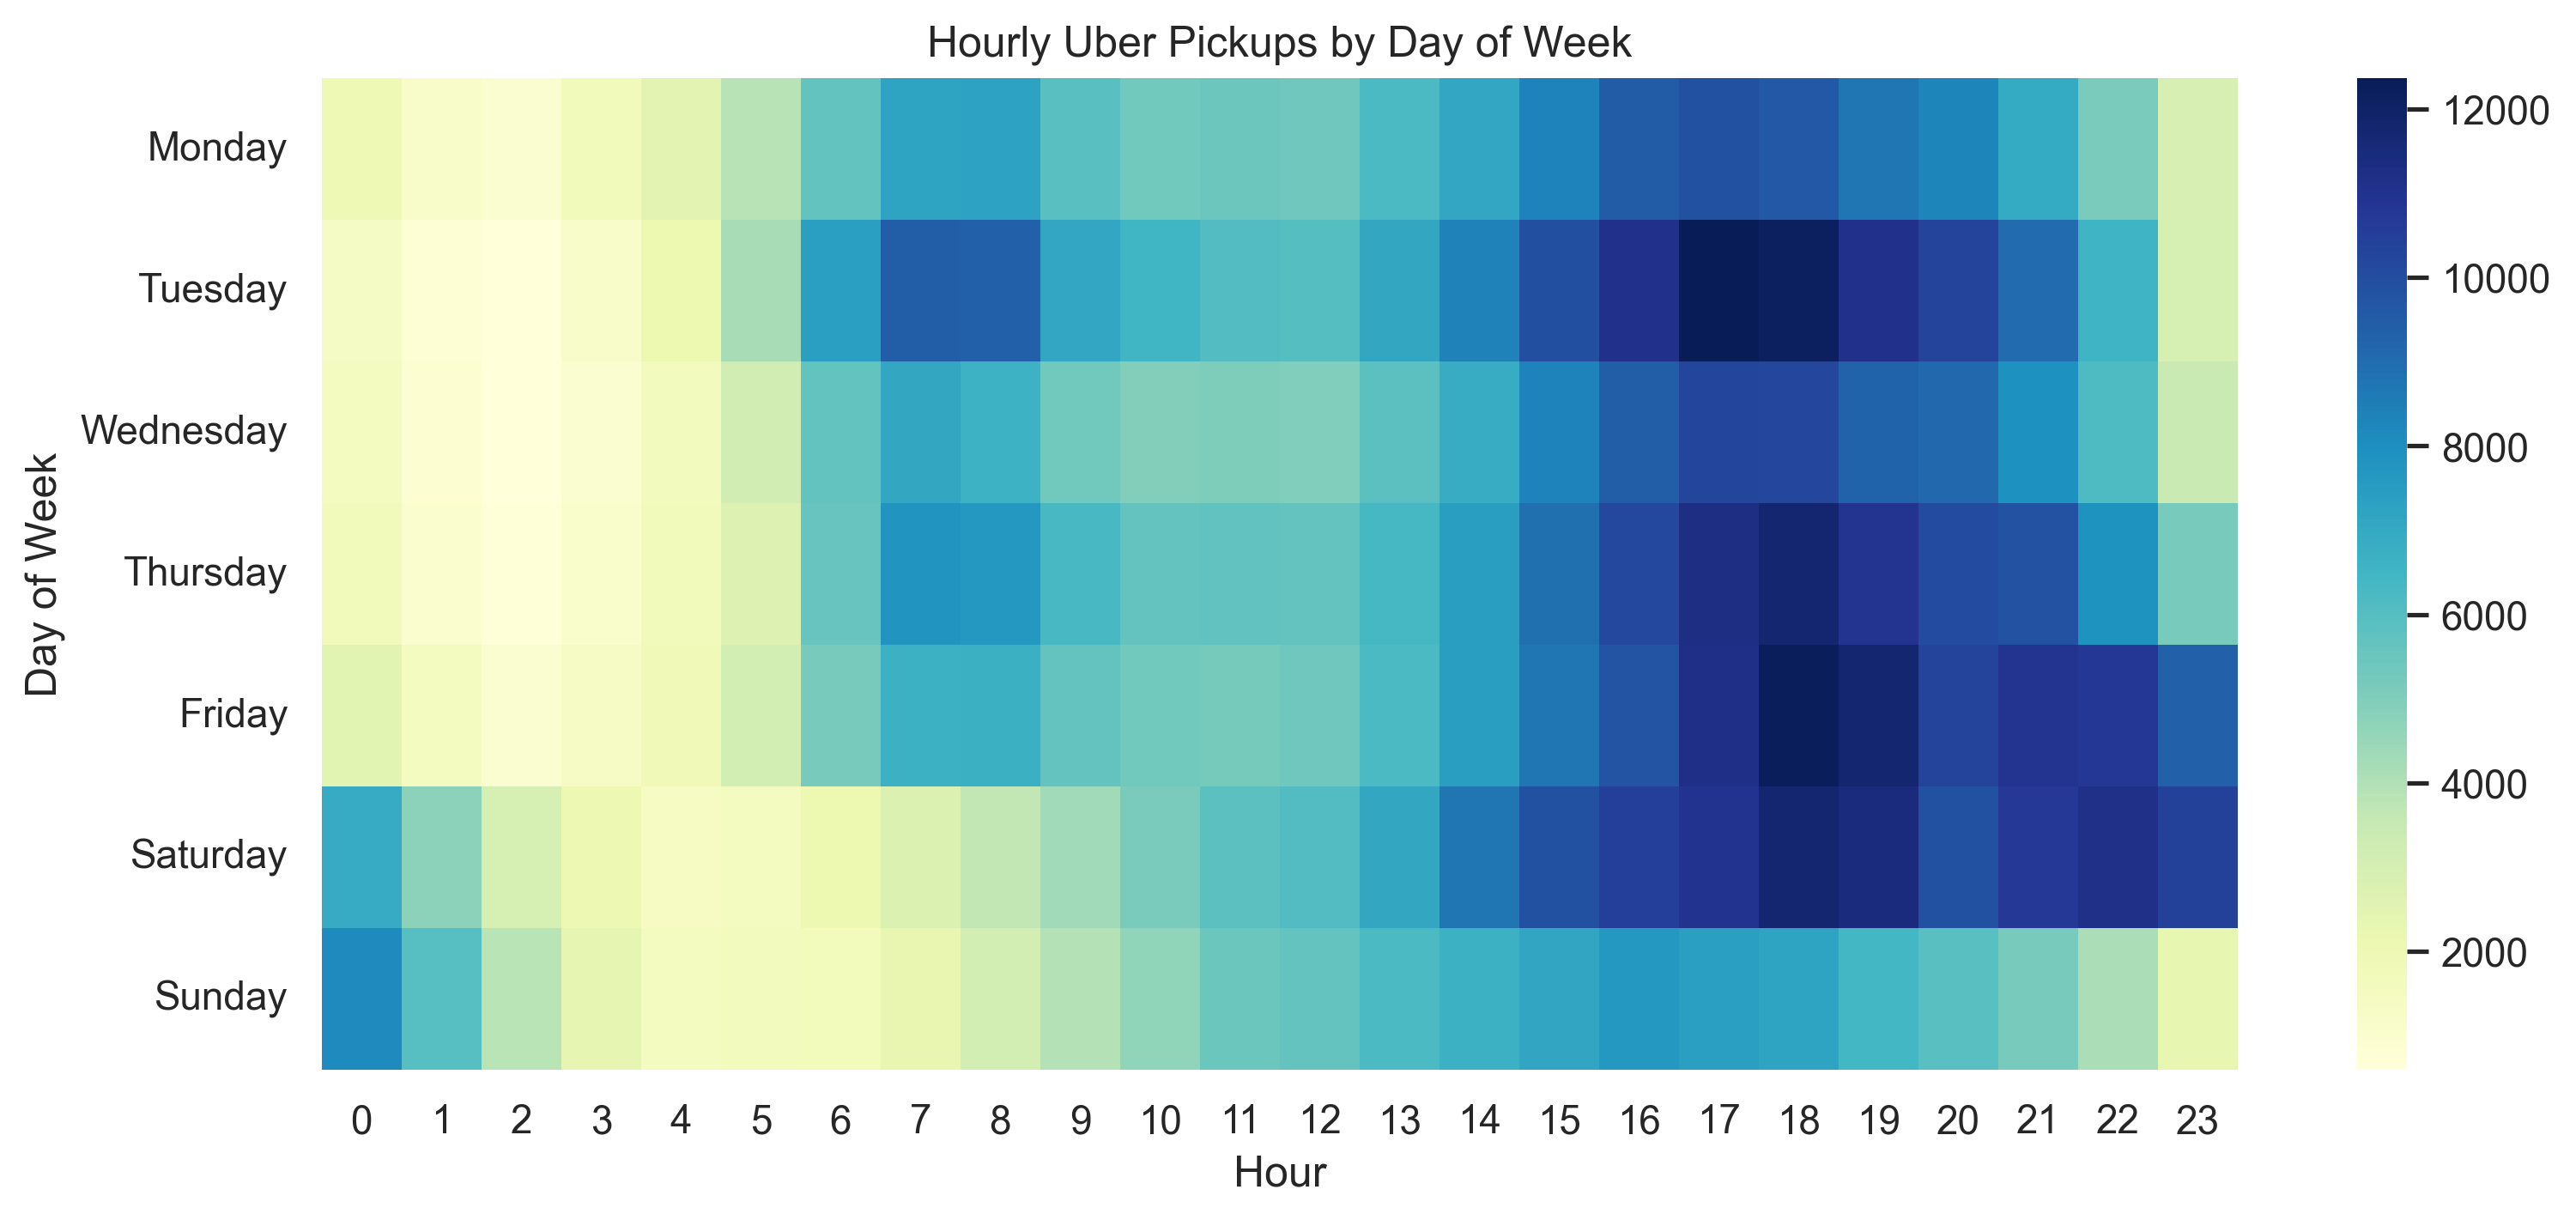

In [31]:
# # pivot_table()로 요일-시간 조합별 탑승 수 만들기
# heatmap_data = df.pivot_table(
#     index="day_of_week",   # 행 기준: 요일
#     columns="hour",        # 열 기준: 시간 (0~23)
#     values="Date/Time",    # 값을 카운트할 대상
#     aggfunc="count"        # 값의 개수를 집계
# ).reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

# # ✅ 1. df.pivot_table(...)
# # 📌 목적:
# # DataFrame을 요일 × 시간 형태의 2차원 테이블로 변환.
# # 각 교차점에 있는 값은 해당 요일-시간에 발생한 우버 픽업 수(count).

# # ✅ 2. .reindex([...])
# # 📌 목적:
# # 요일 순서를 명시적으로 지정해서, pivot_table()이 임의의 순서로 행을 배치하지 않도록 함.

# # Heatmap 그리기
# plt.figure(figsize=(20,10))

# ax = sns.heatmap(
#     heatmap_data, 
#     cmap="YlGnBu", 
#     cbar_kws={'label': 'Number of Pickups'}
# )  # colorbar 라벨 지정

# plt.title("Heatmap of Uber Pickups by Day and Hour", fontsize=20)
# plt.xlabel("Hour of Day", fontsize=20)
# plt.xticks(fontsize=15)  # X축(시간) 레이블 크기 키우기
# plt.ylabel("Day of Week", fontsize=20)
# plt.yticks(fontsize=15, rotation=0)  # Y축(요일) 레이블 크기 키우기 + 회전 (0 = 가로)

# # 오른쪽 색상바(colorbar)의 틱 레이블 폰트 크기 조정
# cbar = ax.collections[0].colorbar   # heatmap의 colorbar 접근
# cbar.ax.tick_params(labelsize=15)     # 색상바 틱 레이블 폰트 크기 조정

# plt.show()


pivot = df.pivot_table(  # 피벗 테이블 생성: 행은 요일, 열은 시간, 값은 'Date/Time'의 개수
    index="day_of_week",        # 행 인덱스를 'day_of_week'으로 설정
    columns="hour",             # 열 인덱스를 'hour'로 설정
    values="Date/Time",         # 집계 대상은 'Date/Time' 열
    aggfunc="count"             # 집계 방식은 개수(count)
)

ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]  # 요일 순서 정의
pivot = pivot.reindex(ordered_days)  # 피벗 테이블의 행 순서를 실제 요일 순서로 재정렬

plt.figure(figsize=(12, 5))  # 그래프 크기를 가로 12, 세로 5로 설정

sns.heatmap(pivot, cmap="YlGnBu")  # 피벗 테이블을 heatmap으로 시각화, 색상 맵은 'YlGnBu' 사용

plt.title("Hourly Uber Pickups by Day of Week")  # 그래프 제목 설정

plt.xlabel("Hour")  # x축 레이블 설정

plt.ylabel("Day of Week")  # y축 레이블 설정

plt.show()  # 그래프 출력


## 4. 패턴 시각화 – 요일별 평균 탑승 수 방사형 차트 (Radar Chart)

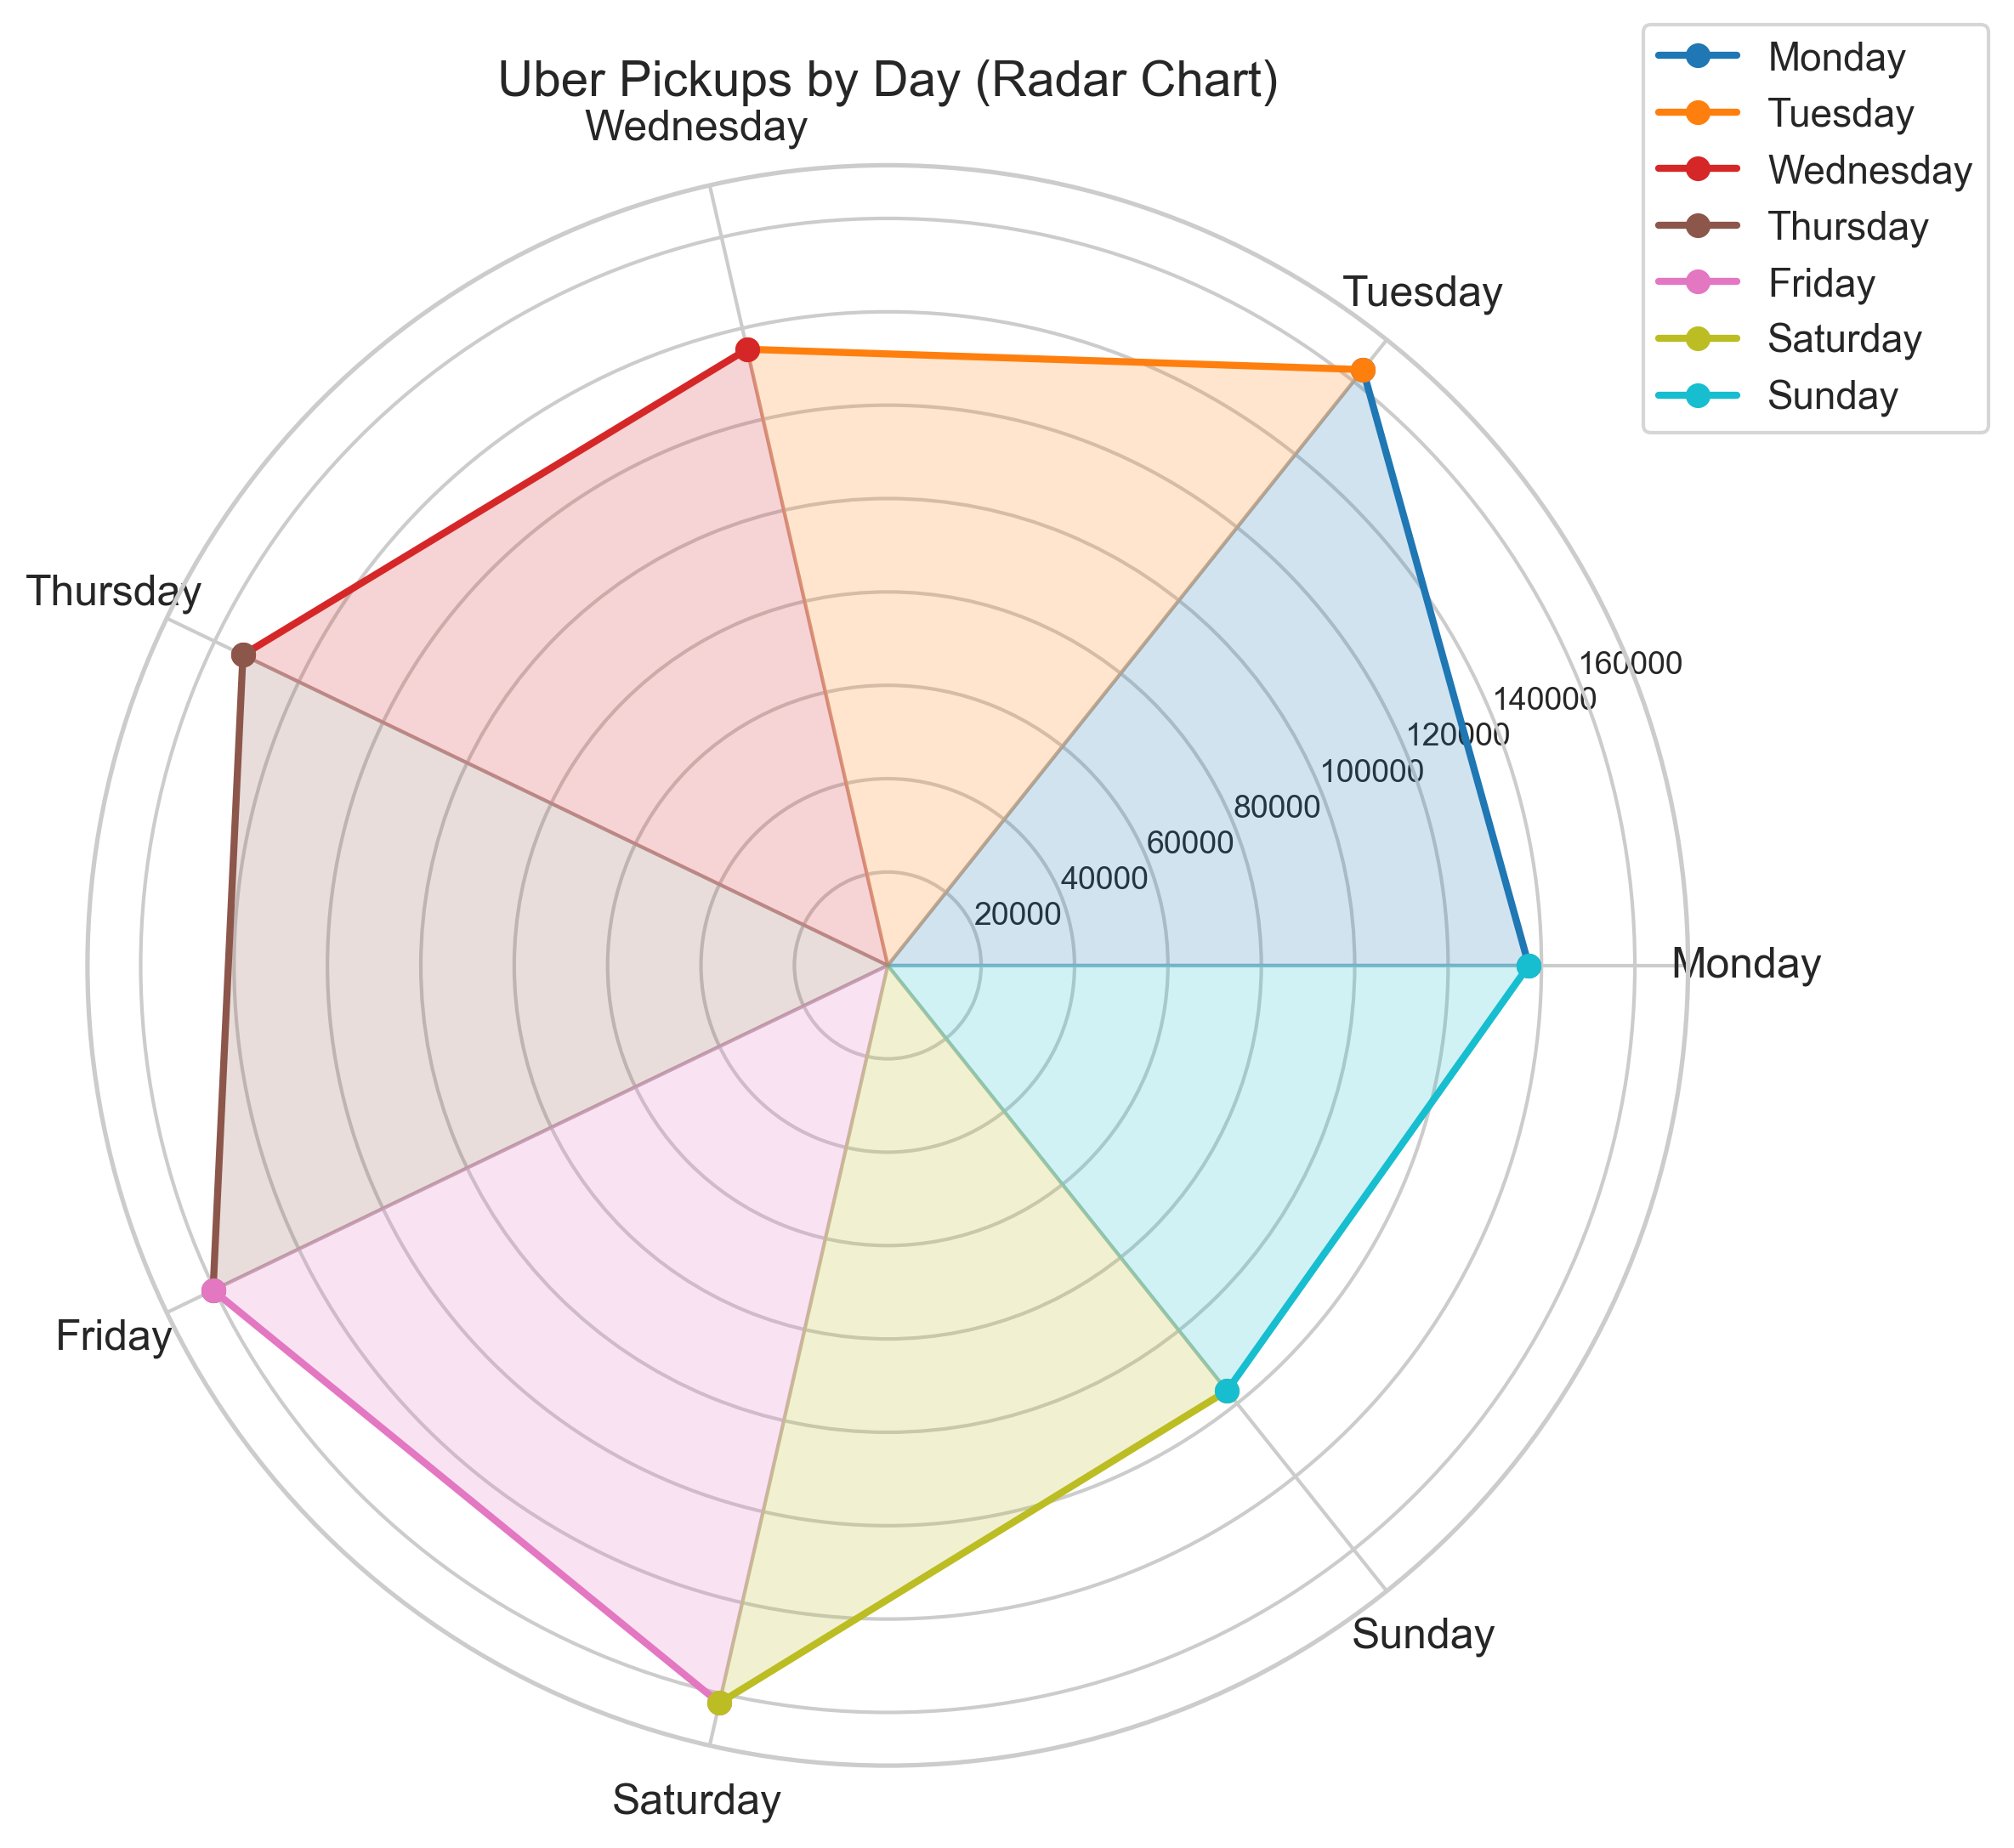

In [32]:
day_avg = df["day_of_week"].value_counts().reindex(ordered_days)  # 요일별 픽업 수를 세고 요일 순서에 맞게 정렬

values = day_avg.values  # 요일별 픽업 수 값 추출
labels = day_avg.index.tolist()  # 요일 레이블 리스트로 추출

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()  # 각 요일에 대한 각도 계산 (360도 균등 분할)
values = np.concatenate((values, [values[0]]))  # 폐곡선을 위해 첫 값을 끝에 추가
angles += [angles[0]]  # 폐곡선을 위해 첫 각도를 끝에 추가

colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))  # 10가지 색상 중에서 요일 수에 맞춰 색상 선택

fig, ax = plt.subplots(subplot_kw={'polar': True}, figsize=(8, 8))  # 폴라 좌표계(원형 차트) 설정

# 각 구간별 선과 채움 표시
for i in range(len(labels)):
    ax.plot(  # 각 구간의 외곽선 그리기
        [angles[i], angles[i+1]], 
        [values[i], values[i+1]], 
        marker='o', color=colors[i], linewidth=2, label=labels[i]
    )
    ax.fill(  # 각 구간의 내부 색 채우기
        [angles[i], angles[i+1], angles[i+1], angles[i]], 
        [0, 0, values[i+1], values[i]], 
        color=colors[i], alpha=0.2
    )

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=12)  # 각도 라벨(요일) 설정
ax.tick_params(axis='y', labelsize=9)  # 반지름 축 눈금의 글꼴 크기 조절

for label in ax.get_yaxis().get_ticklabels():  # 반지름 눈금 라벨 회전 및 폰트 크기 설정
    label.set_rotation(0)
    label.set_fontsize(9)

plt.title("Uber Pickups by Day (Radar Chart)", fontsize=14, pad=20)  # 차트 제목 설정
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))  # 범례 위치 조정
plt.tight_layout()  # 레이아웃 자동 정렬
plt.show()  # 차트 출력

## 5. 분포 시각화 - 시간대별 분포 (히스토그램)

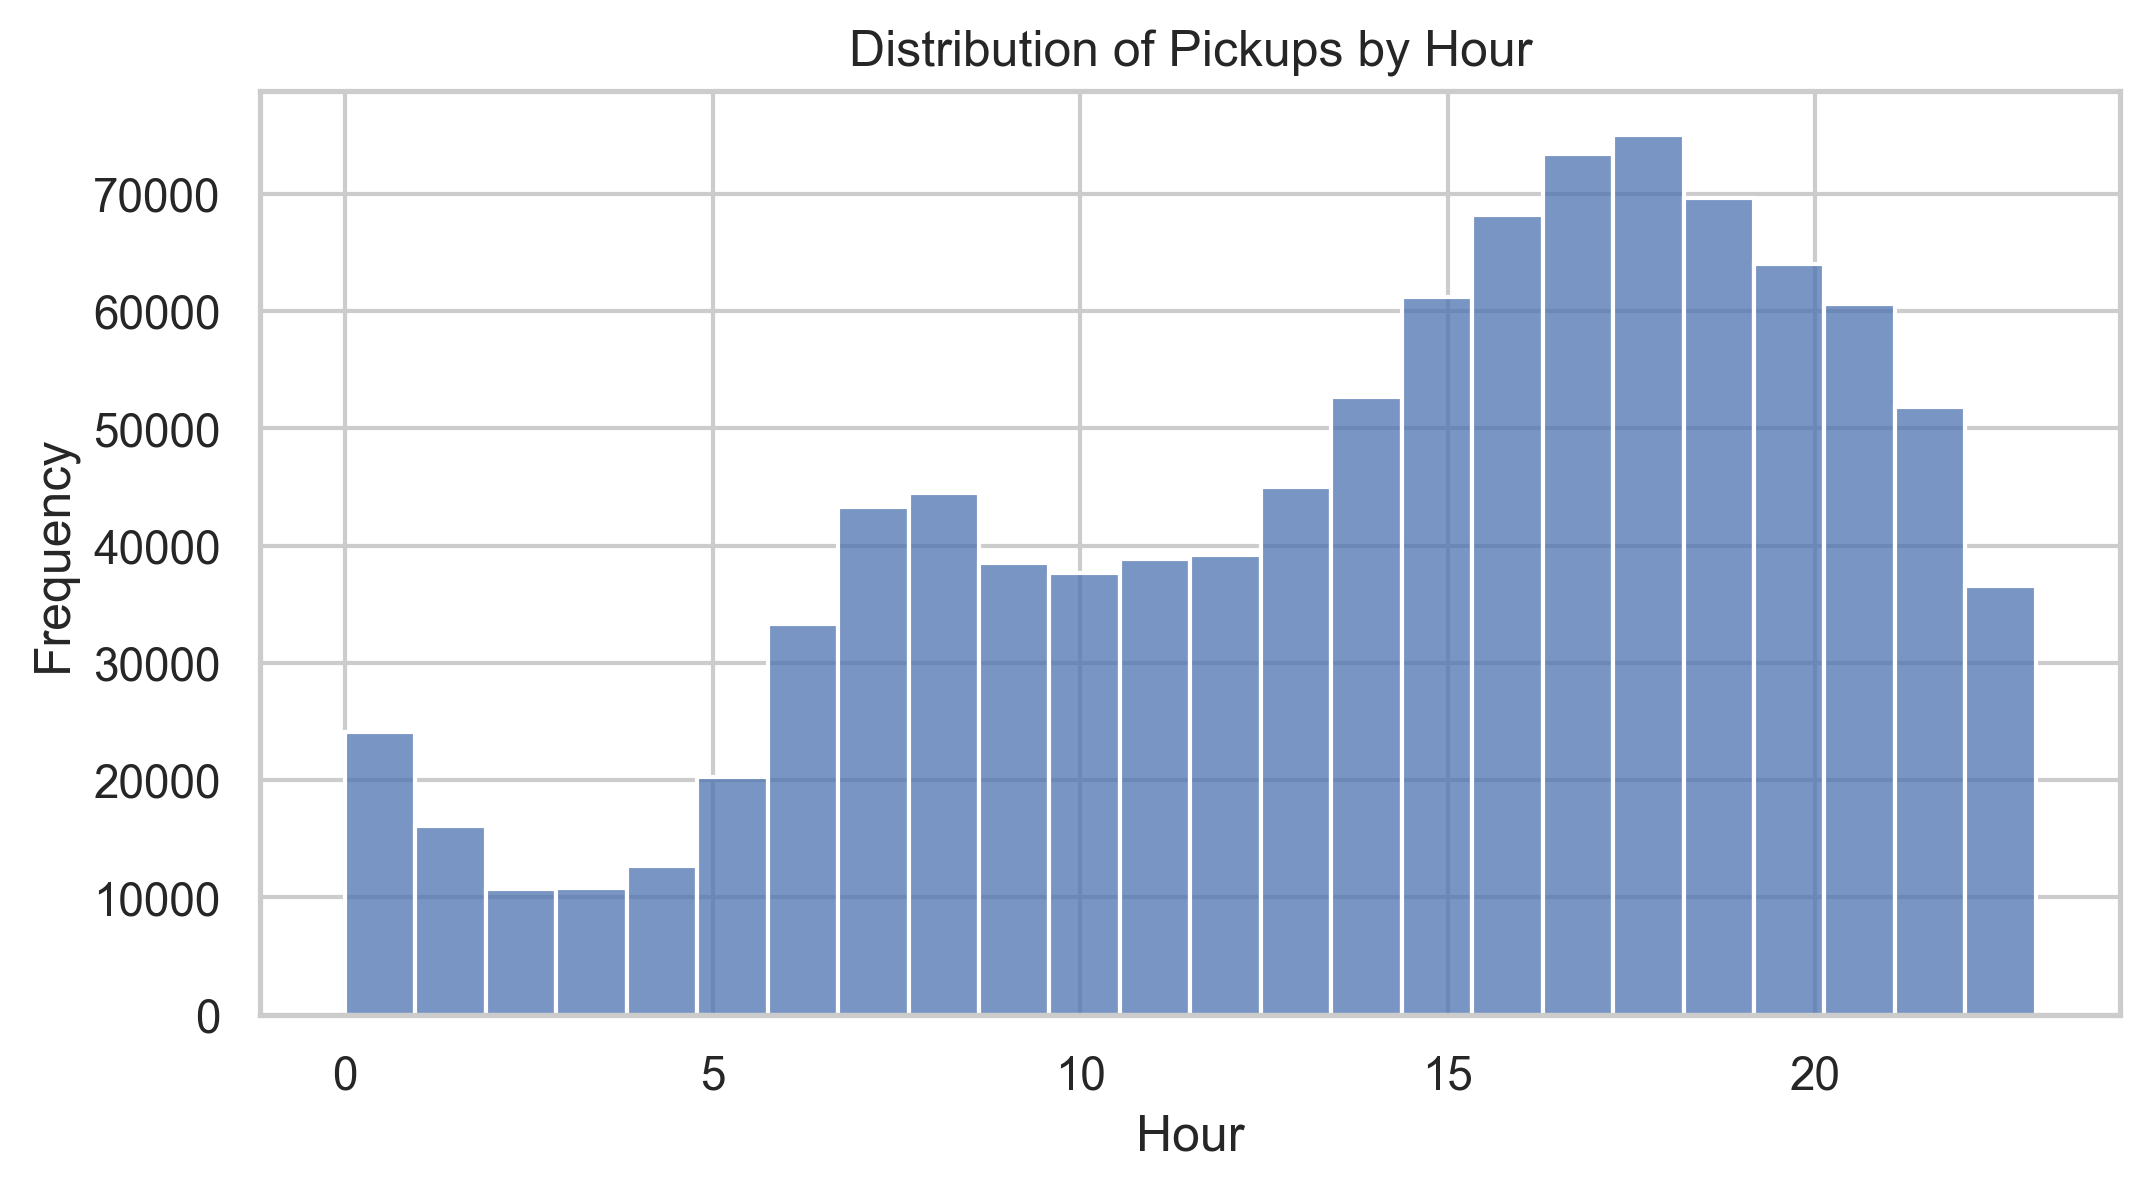

In [33]:
plt.figure(figsize=(8, 4))  # 그래프 크기를 가로 8, 세로 4로 설정

sns.histplot(df["hour"], bins=24, kde=False) 
# 'hour' 열을 기준으로 히스토그램 생성 (24시간 기준으로 구간 나눔), KDE 곡선은 비활성화

plt.title("Distribution of Pickups by Hour")  # 그래프 제목 설정
plt.xlabel("Hour")  # x축 레이블 설정
plt.ylabel("Frequency")  # y축 레이블 설정

plt.show()  # 그래프 출력

## 6. 관계 시각화 - 위도 vs 경도 산점도

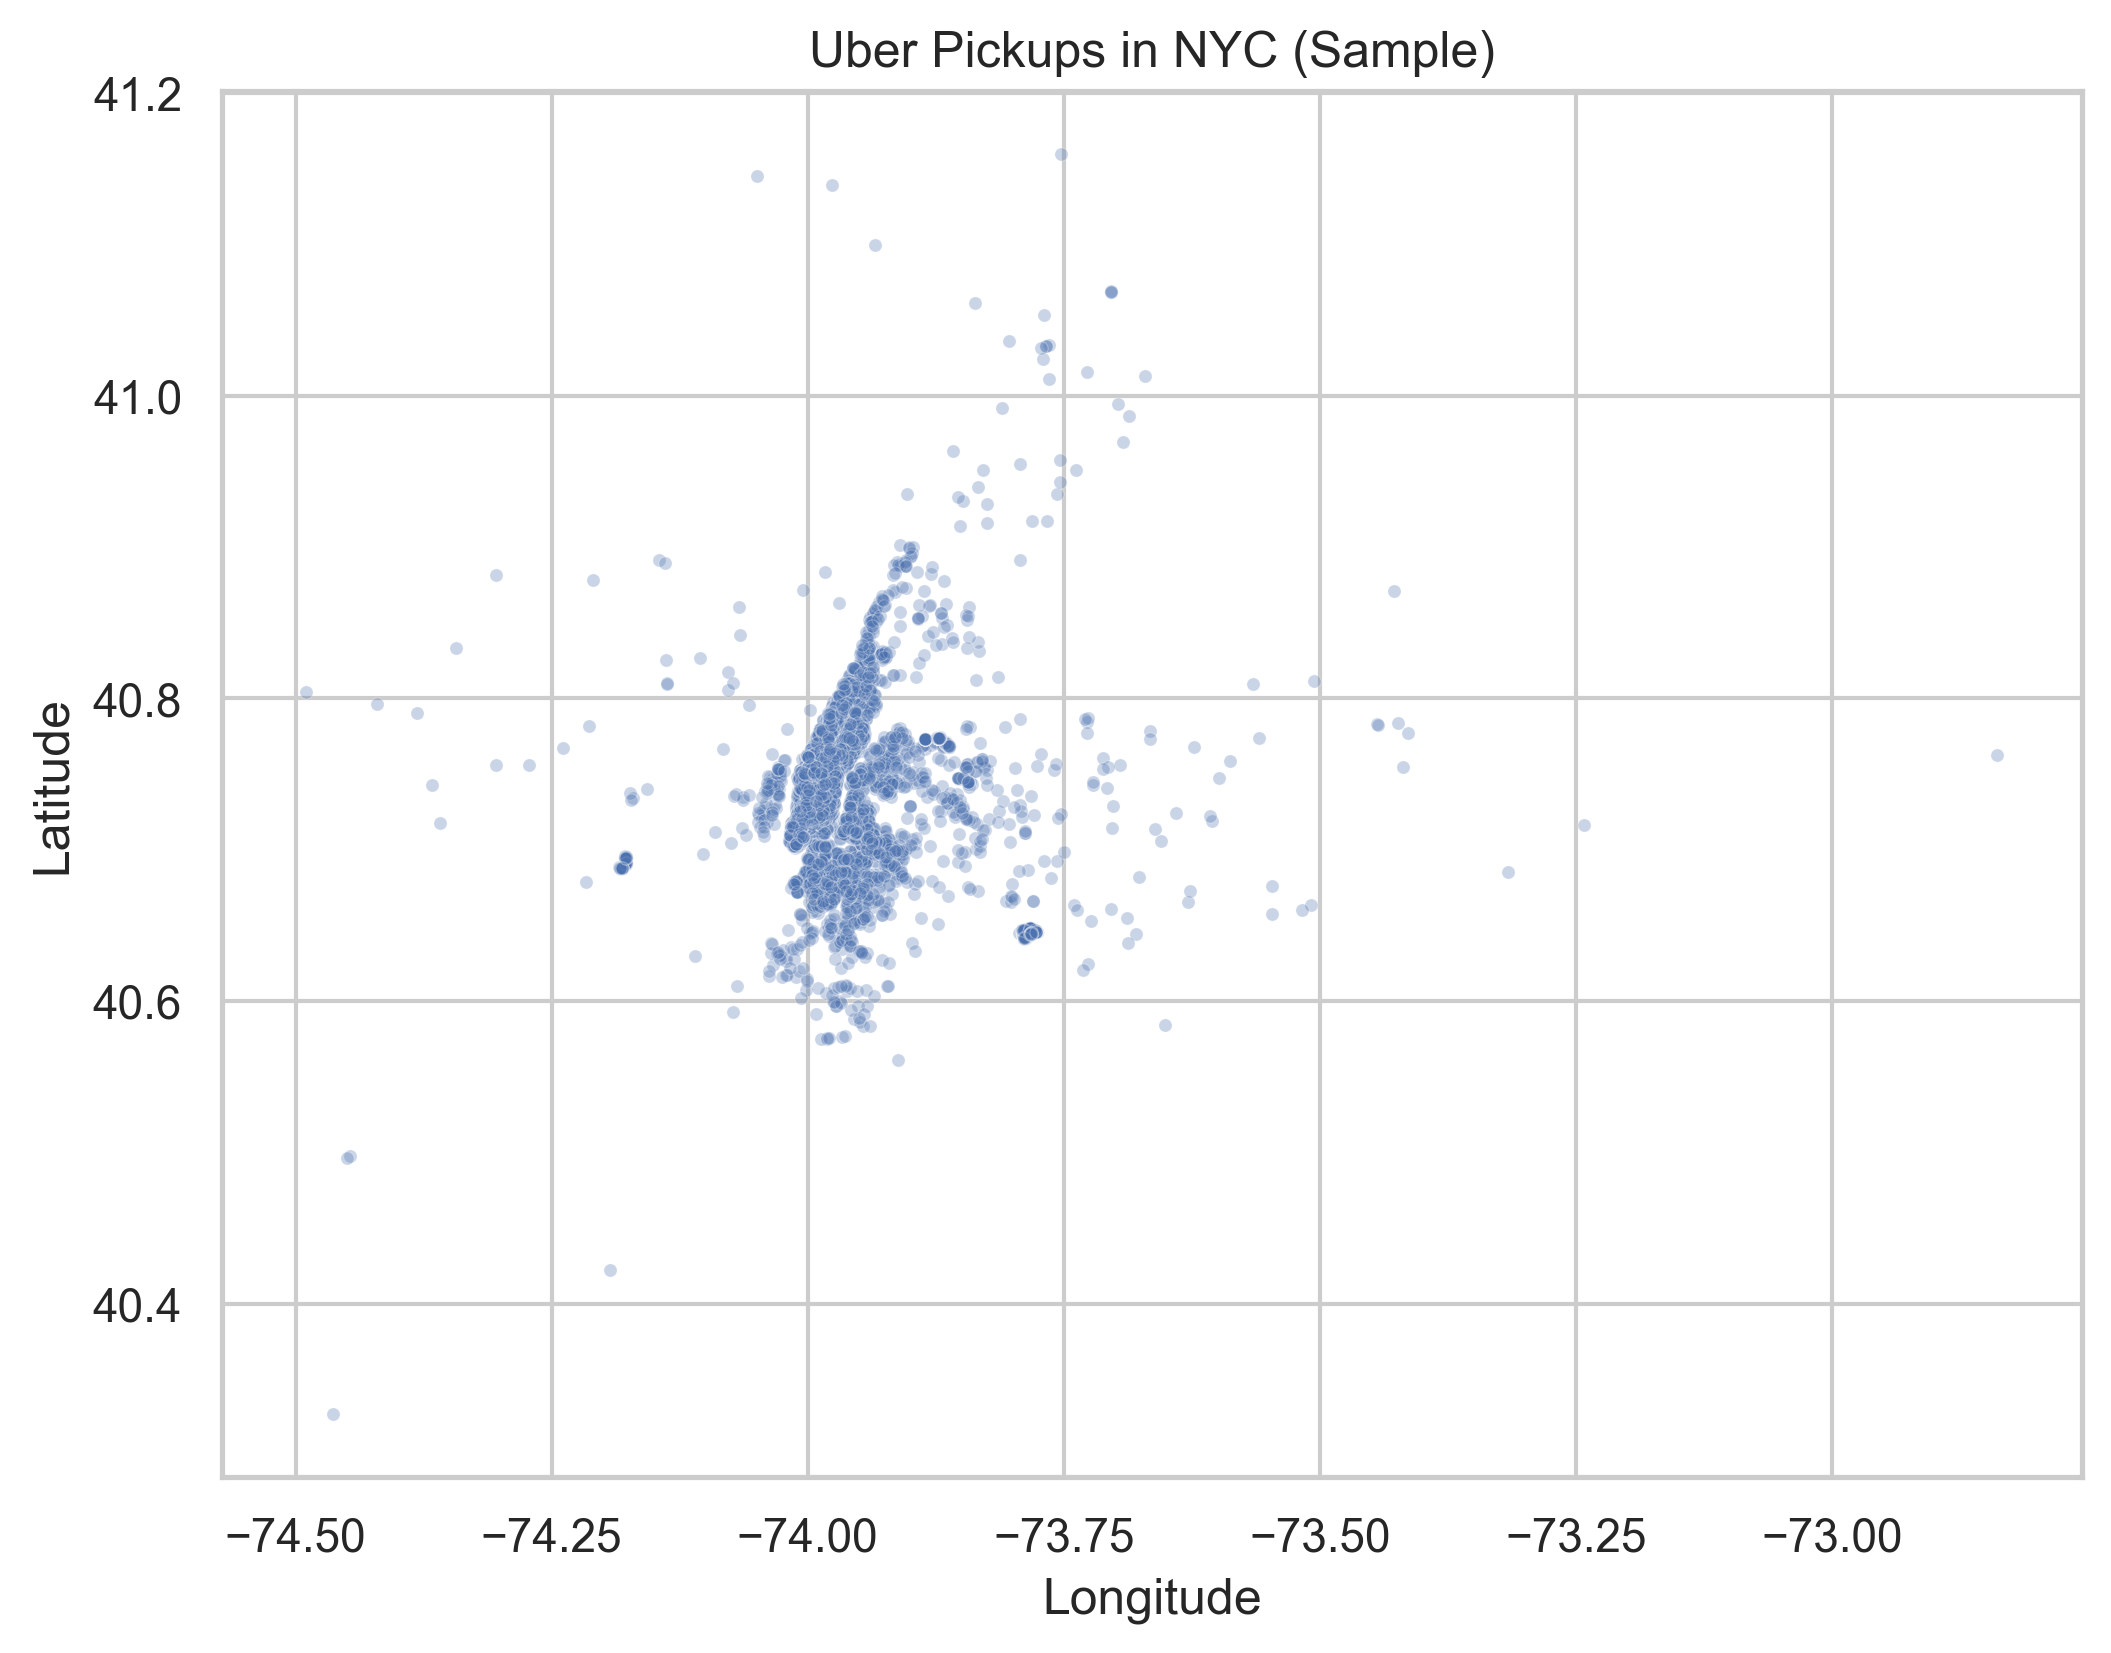

In [ ]:
sample_df = df.sample(10000)  # 전체 데이터에서 10,000개 샘플링 (속도 향상을 위해 일부만 사용)

plt.figure(figsize=(8, 6))  # 그래프 크기를 가로 8, 세로 6으로 설정

sns.scatterplot(  # 산점도 생성
    x="Lon",               # x축에 경도(Lon) 설정
    y="Lat",               # y축에 위도(Lat) 설정
    data=sample_df,        # 샘플링된 데이터 사용
    alpha=0.3,             # 점의 투명도 설정 (0.3으로 겹침을 줄이고 밀도 시각화)
    s=10                   # 점의 크기를 10으로 설정 (작게)
)

plt.title("Uber Pickups in NYC (Sample)")  # 그래프 제목 설정
plt.xlabel("Longitude")  # x축 레이블 설정 (경도)
plt.ylabel("Latitude")  # y축 레이블 설정 (위도)

plt.show()  # 그래프 출력

## 7. 공간 시각화 - Folium 지도 시각화

In [36]:
m = folium.Map(location=[40.75, -73.95], zoom_start=12)  # 뉴욕시 중심 좌표 기준으로 지도를 생성하고 초기 줌 레벨을 12로 설정

# sample_df의 각 행에 대해 반복하면서 지도에 CircleMarker 추가
for _, row in sample_df.iterrows():
    folium.CircleMarker(  # 원형 마커 추가
        location=[row["Lat"], row["Lon"]],  # 마커의 위치 (위도, 경도)
        radius=1,                           # 마커 반지름 (픽셀 단위, 작게 설정)
        color="blue",                       # 테두리 색상
        fill=True,                          # 내부 채움 여부
        fill_opacity=0.6                    # 채움의 투명도
    ).add_to(m)  # 생성한 마커를 지도 객체 m에 추가

# Jupyter Notebook 환경에서 지도를 시각적으로 출력
display(m)

## 8. 비교 시각화 확장 - 박스플롯 (요일별 분포)

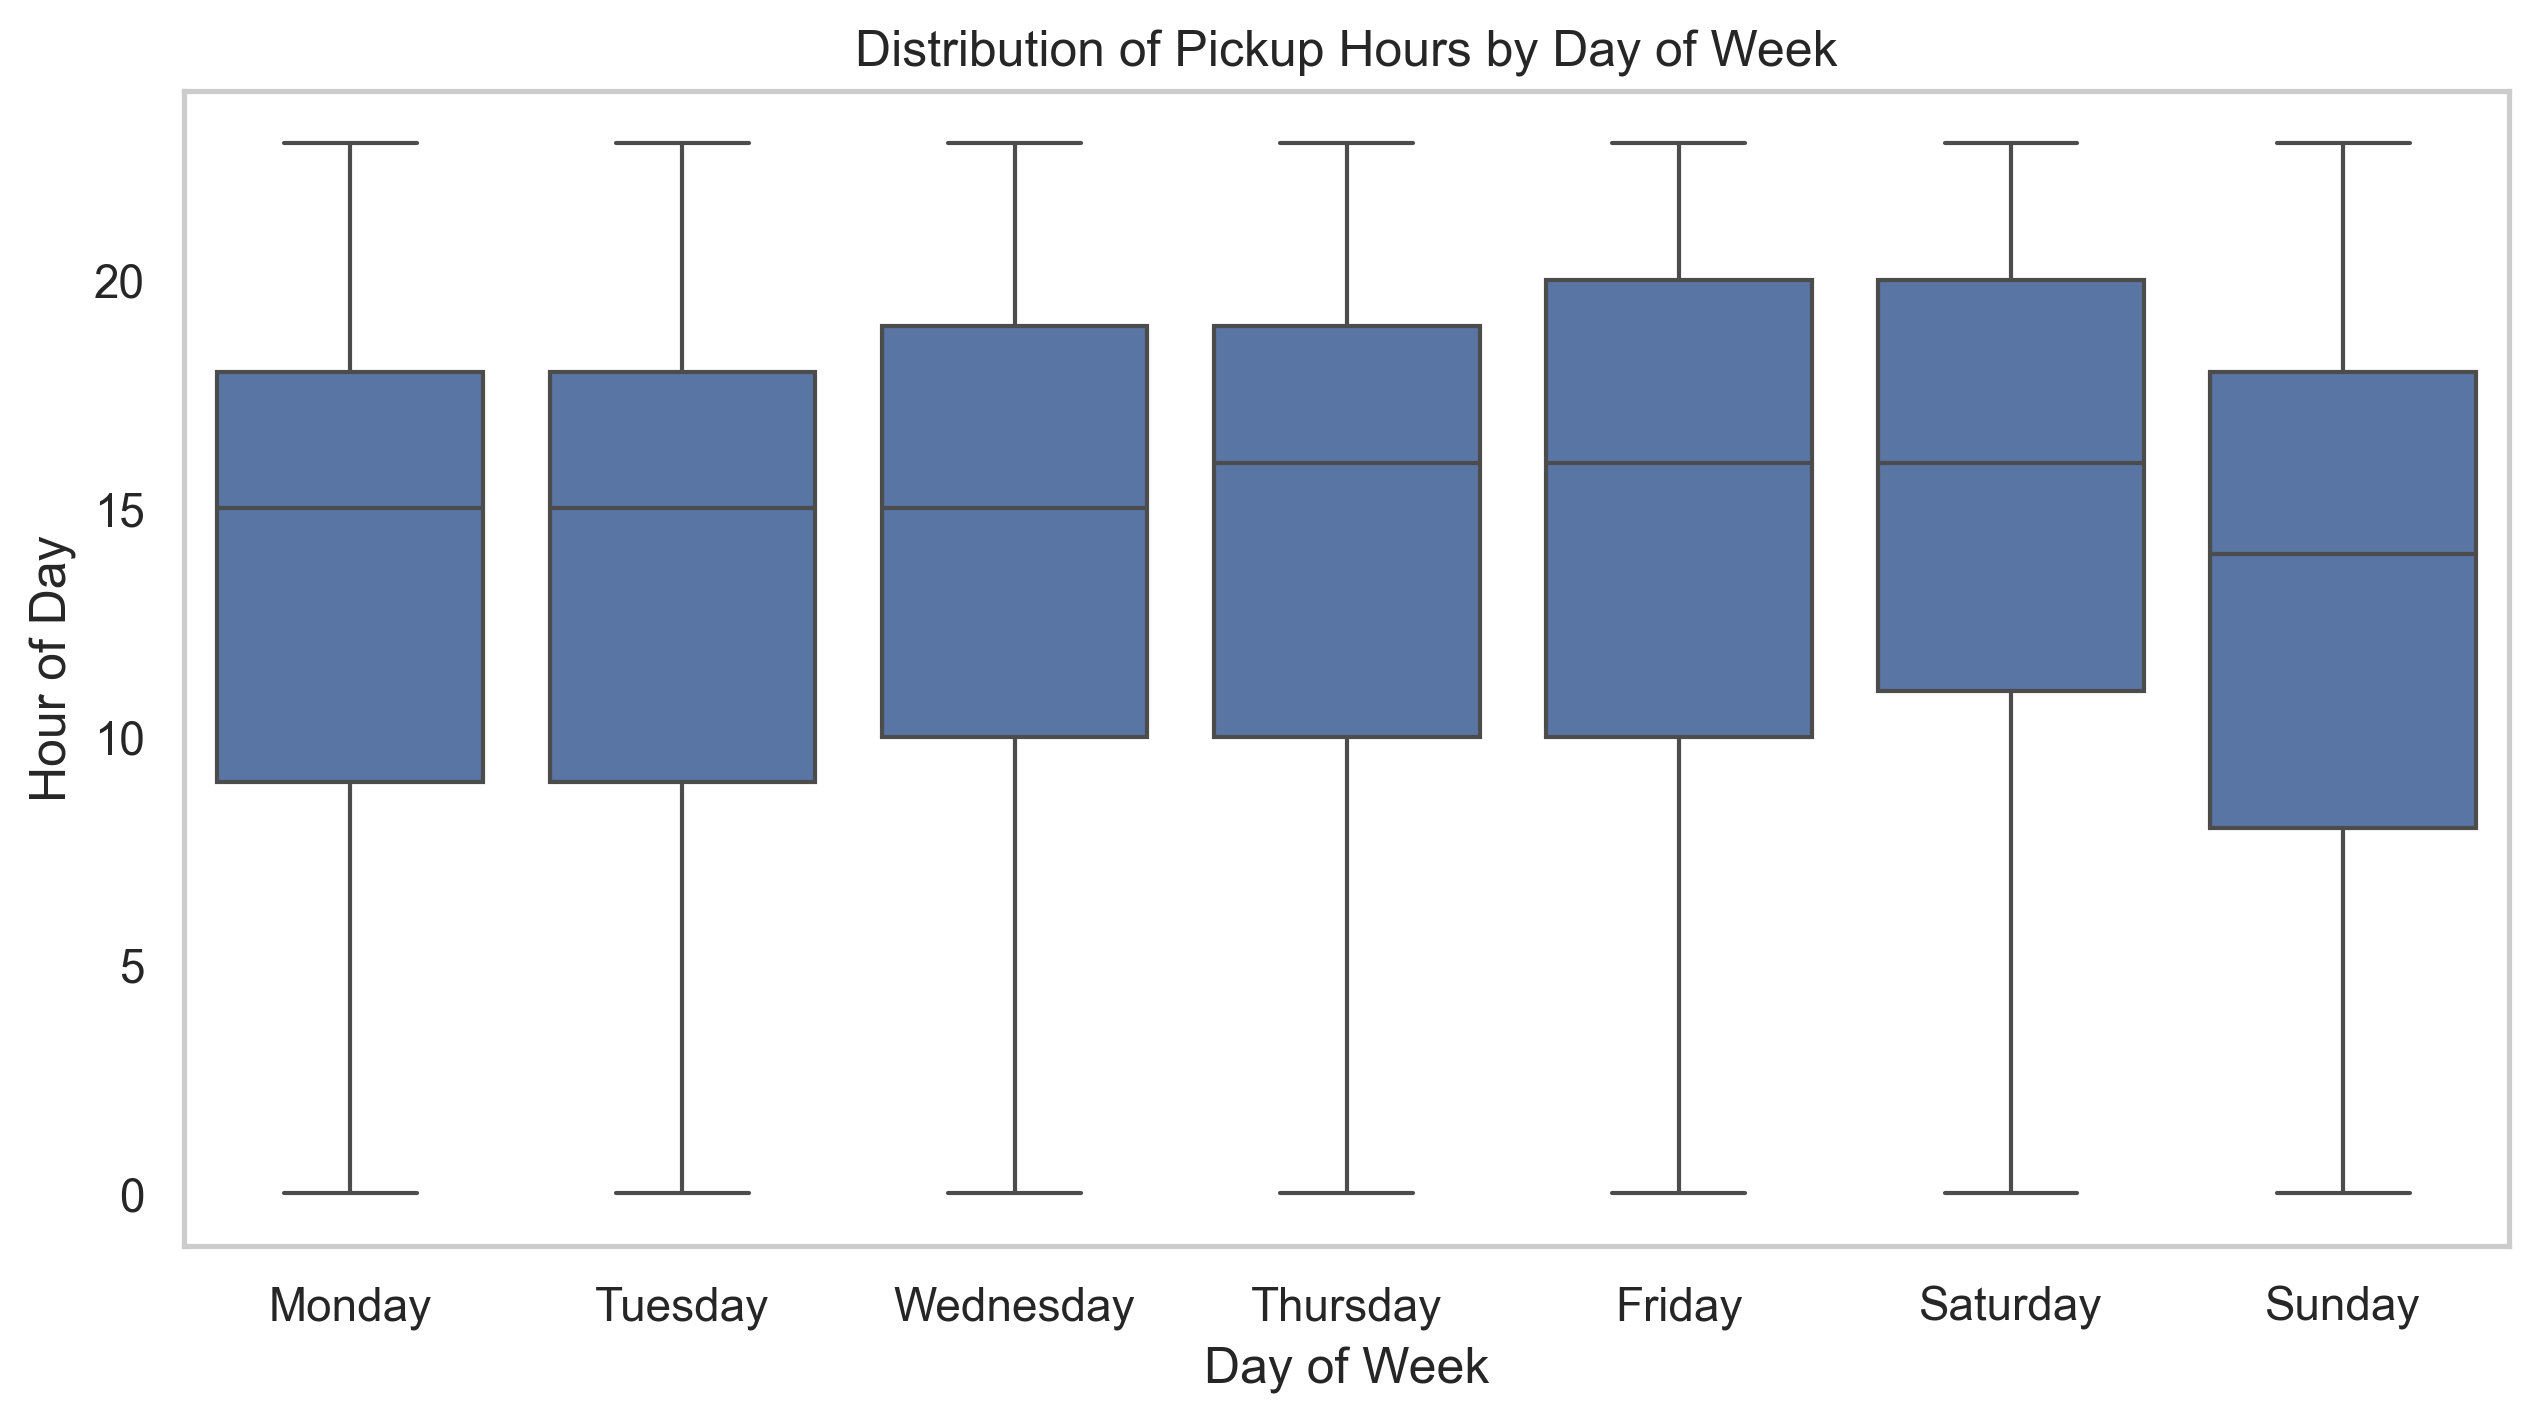

In [37]:
plt.figure(figsize=(10, 5))  # 그래프 크기를 가로 10, 세로 5로 설정

sns.boxplot(  # 박스플롯 생성 (요일별 픽업 시간 분포 확인)
    x="day_of_week",           # x축: 요일
    y="hour",                  # y축: 픽업이 발생한 시간 (0~23)
    data=df,                   # 사용 데이터프레임
    order=ordered_days         # 요일 순서를 월요일~일요일로 명시적으로 지정
)

plt.title("Distribution of Pickup Hours by Day of Week")  # 그래프 제목 설정
plt.xlabel("Day of Week")  # x축 레이블 설정
plt.ylabel("Hour of Day")  # y축 레이블 설정
plt.grid(axis='y')  # y축 방향으로만 격자선 표시 (픽업 시간대를 명확히 보기 위해)

plt.show()  # 그래프 출력

